# OSS Pulse: modeling

Leakage check, model comparison, hyperparameter tuning and export of the final model. Exploratory analysis lives in `01_eda.ipynb`.

Run it top to bottom (**Kernel -> Restart & Run All**). Figures are saved to `docs/images/`, the model to `src/model/`, and the stats used by the web app to `web/data/stats.json`.

In [1]:
import json
import os
import time

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
                                     StratifiedKFold, train_test_split)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_PATH = "../data/processed/repos_clean.csv"
IMG_DIR = "../docs/images"
MODEL_DIR = "../src/model"
WEB_DATA_DIR = "../web/data"

for directory in (IMG_DIR, MODEL_DIR, WEB_DATA_DIR):
    os.makedirs(directory, exist_ok=True)


def save_fig(name):
    plt.savefig(f"{IMG_DIR}/{name}.png", dpi=150, bbox_inches="tight")


df = pd.read_csv(DATA_PATH)
df.shape

(2397, 19)

## 1. Data split

A single stratified 80/20 split is reused everywhere. The test set is only used to report final numbers, never to choose hyperparameters or the final model.

In [2]:
FEATURES_ALL = ["stargazers_count", "forks_count", "first_month_commits", "contributors_count",
                "issue_close_ratio", "commits_per_contributor", "age_days",
                "has_license", "has_wiki", "has_description"]
FEATURES = [c for c in FEATURES_ALL if c != "age_days"]  # age_days is excluded, see next cell

y = df["label"]
X_train_all, X_test_all, y_train, y_test = train_test_split(
    df[FEATURES_ALL], y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_test = X_train_all[FEATURES], X_test_all[FEATURES]

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test balance:", y_test.value_counts(normalize=True).round(3).to_dict())

Train: (1917, 9) | Test: (480, 9)
Train balance: {0: 0.69, 1: 0.31}
Test balance: {0: 0.69, 1: 0.31}


### 1.1 Structural leakage check: `age_days`

The label is "pushed in the last 180 days", so older repos have mechanically had more chances to fall into an inactive window. A Random Forest trained with `age_days` ranks it as the most important feature even though its correlation with the label is near zero. The model without it is used from here on.

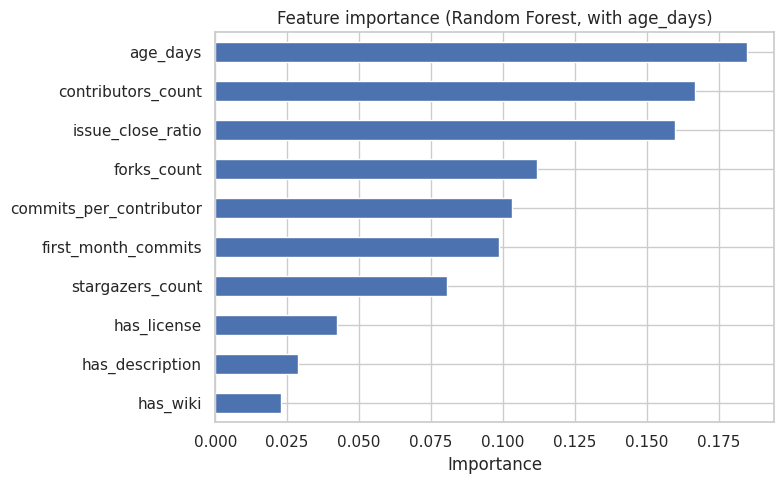

Random Forest AUC with age_days: 0.851


In [3]:
rf_with_age = RandomForestClassifier(class_weight="balanced", n_estimators=200, random_state=RANDOM_STATE)
rf_with_age.fit(X_train_all, y_train)
auc_with_age = roc_auc_score(y_test, rf_with_age.predict_proba(X_test_all)[:, 1])

importances_with_age = pd.Series(rf_with_age.feature_importances_, index=FEATURES_ALL).sort_values()
importances_with_age.plot(kind="barh", figsize=(8, 5),
                          title="Feature importance (Random Forest, with age_days)")
plt.xlabel("Importance")
plt.tight_layout()
save_fig("feature_importance_with_age")
plt.show()

print(f"Random Forest AUC with age_days: {auc_with_age:.3f}")

## 2. Four model families, default hyperparameters

All models use the same features (no `age_days`). Scale-sensitive models (logistic regression, MLP) get the scaler inside a `Pipeline`, so it is fitted on training data only.

In [4]:
def evaluate(model, X, y_true):
    proba = model.predict_proba(X)[:, 1]
    report = classification_report(y_true, model.predict(X), output_dict=True,
                                   target_names=["Abandoned", "Active"])
    return {
        "auc": roc_auc_score(y_true, proba),
        "accuracy": report["accuracy"],
        "precision_active": report["Active"]["precision"],
        "recall_active": report["Active"]["recall"],
    }


default_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=200,
                                            random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Neural Network (MLP)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=RANDOM_STATE)),
    ]),
}

rows = []
for name, model in default_models.items():
    model.fit(X_train, y_train)
    rows.append({"model": name, **evaluate(model, X_test, y_test)})

default_df = pd.DataFrame(rows).sort_values("auc", ascending=False).round(3).reset_index(drop=True)
default_df

,model,auc,accuracy,precision_active,recall_active
0,Gradient Boosting,0.823,0.802,0.701,0.631
1,Random Forest,0.817,0.792,0.667,0.658
2,Logistic Regression,0.800,0.694,0.505,0.745
3,Neural Network (MLP),0.789,0.808,0.739,0.591


## 3. Hyperparameter tuning

Randomized / grid search with stratified 5-fold cross-validation on the **training set only**. The final model is chosen by cross-validated AUC, not by test AUC.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

searches = {
    "Logistic Regression": GridSearchCV(
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(class_weight="balanced", max_iter=2000)),
        ]),
        {"clf__C": [0.01, 0.1, 1, 10, 100]},
        scoring="roc_auc", cv=cv, n_jobs=-1,
    ),
    "Random Forest": RandomizedSearchCV(
        RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        {
            "n_estimators": [100, 200, 400],
            "max_depth": [None, 5, 10, 20],
            "min_samples_leaf": [1, 3, 5, 10],
            "max_features": ["sqrt", 0.5, 1.0],
        },
        n_iter=25, scoring="roc_auc", cv=cv, n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": RandomizedSearchCV(
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {
            "n_estimators": [100, 200, 300, 500],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [2, 3, 4, 5],
            "subsample": [0.7, 0.85, 1.0],
            "min_samples_leaf": [1, 5, 10],
        },
        n_iter=30, scoring="roc_auc", cv=cv, n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "Neural Network (MLP)": RandomizedSearchCV(
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(max_iter=2000, early_stopping=True, random_state=RANDOM_STATE)),
        ]),
        {
            "clf__hidden_layer_sizes": [(16,), (32,), (32, 16), (64, 32)],
            "clf__alpha": [1e-4, 1e-3, 1e-2, 1e-1],
            "clf__learning_rate_init": [1e-3, 5e-3, 1e-2],
        },
        n_iter=20, scoring="roc_auc", cv=cv, n_jobs=-1, random_state=RANDOM_STATE,
    ),
}

best_models = {}
rows = []
for name, search in searches.items():
    start = time.time()
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_

    # The test set is touched once per model, only to report the number
    test_auc = roc_auc_score(y_test, search.best_estimator_.predict_proba(X_test)[:, 1])
    rows.append({
        "model": name,
        "cv_auc": search.best_score_,
        "tuned_test_auc": test_auc,
        "seconds": time.time() - start,
        "best_params": search.best_params_,
    })
    print(f"{name} done in {rows[-1]['seconds']:.0f}s")

tuning_df = (pd.DataFrame(rows)
             .sort_values("cv_auc", ascending=False)
             .round({"cv_auc": 3, "tuned_test_auc": 3, "seconds": 0})
             .reset_index(drop=True))
tuning_df

Logistic Regression done in 3s
Random Forest done in 9s
Gradient Boosting done in 14s
Neural Network (MLP) done in 1s


,model,cv_auc,tuned_test_auc,seconds,best_params
0,Gradient Boosting,0.853,0.826,14.0,"{'subsample': 0.85, 'n_estimators': 200, 'min_..."
1,Random Forest,0.850,0.835,9.0,"{'n_estimators': 100, 'min_samples_leaf': 10, ..."
2,Neural Network (MLP),0.821,0.804,1.0,"{'clf__learning_rate_init': 0.001, 'clf__hidde..."
3,Logistic Regression,0.814,0.800,3.0,{'clf__C': 10}


In [6]:
summary = (default_df[["model", "auc"]].rename(columns={"auc": "default_test_auc"})
           .merge(tuning_df[["model", "cv_auc", "tuned_test_auc"]], on="model")
           .sort_values("cv_auc", ascending=False)
           .reset_index(drop=True))
summary

,model,default_test_auc,cv_auc,tuned_test_auc
0,Gradient Boosting,0.823,0.853,0.826
1,Random Forest,0.817,0.850,0.835
2,Neural Network (MLP),0.789,0.821,0.804
3,Logistic Regression,0.800,0.814,0.800


## 4. Final model

Selected by cross-validated AUC (the first row of `tuning_df`). Differences of about 0.01 AUC between the top models are within the noise of a test set of 480 rows, so the selection rule matters more than the test ranking.

In [7]:
final_name = tuning_df.iloc[0]["model"]
final_model = best_models[final_name]
final_test_auc = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])

print(f"Final model: {final_name}")
print("Best params:", tuning_df.iloc[0]["best_params"])
print(f"Test AUC: {final_test_auc:.3f}\n")
print(classification_report(y_test, final_model.predict(X_test), target_names=["Abandoned", "Active"]))

Final model: Gradient Boosting
Best params: {'subsample': 0.85, 'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 2, 'learning_rate': 0.05}
Test AUC: 0.826

              precision    recall  f1-score   support

   Abandoned       0.85      0.90      0.87       331
      Active       0.74      0.64      0.69       149

    accuracy                           0.82       480
   macro avg       0.79      0.77      0.78       480
weighted avg       0.81      0.82      0.81       480



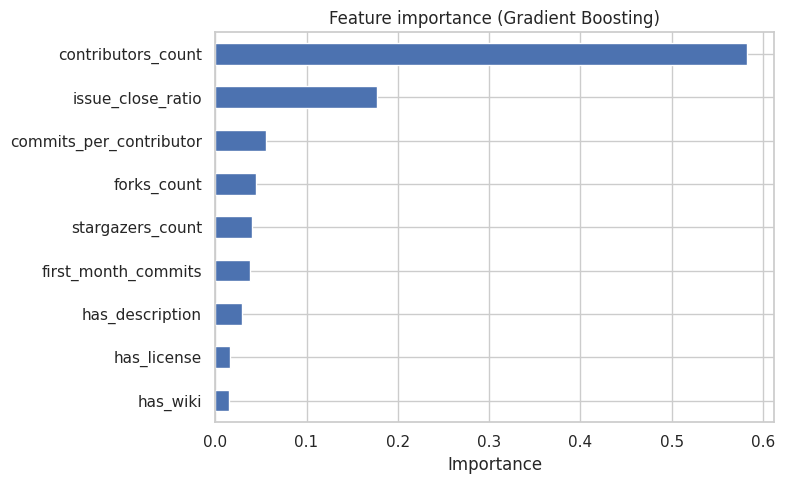

In [8]:
final_importances = None
if hasattr(final_model, "feature_importances_"):
    final_importances = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values()
    final_importances.plot(kind="barh", figsize=(8, 5), title=f"Feature importance ({final_name})")
    plt.xlabel("Importance")
    plt.tight_layout()
    save_fig("feature_importance_final")
    plt.show()

## 5. Export

Saves the model for the Flask backend and the static stats used by the web page.

In [9]:
joblib.dump(final_model, f"{MODEL_DIR}/repo_survival_model.pkl")
joblib.dump(FEATURES, f"{MODEL_DIR}/feature_cols.pkl")

stats = {
    "total_repos": int(len(df)),
    "active_pct": round(float((df["label"] == 1).mean() * 100), 1),
    "abandoned_pct": round(float((df["label"] == 0).mean() * 100), 1),
    "feature_importance": ({k: float(v) for k, v in final_importances.items()}
                           if final_importances is not None else {}),
    "auc": round(float(final_test_auc), 3),
}
with open(f"{WEB_DATA_DIR}/stats.json", "w") as f:
    json.dump(stats, f, indent=2)

print(f"Saved {final_name} and stats.json (AUC {stats['auc']})")

Saved Gradient Boosting and stats.json (AUC 0.826)
